# 02 - Análise Exploratória dos Dados

## Objetivo

Investigar o comportamento da renovação de apólices e identificar características
dos clientes, apólices e veículos associadas a maiores ou menores taxas de renovação.

### Pergunta de negócio

> Quais características estão associadas à renovação ou não renovação das apólices?

Nesta etapa serão analisadas principalmente:
- Idade;
- Tempo de Apólice;
- Prêmio;
- Perfil de Risco;
- Região;
- Uso do Veículo;
- Forma de pagamento do prêmio.

Os resultados desta etapa serão utilizados para formular hipóteses que serão
investigadas estatisticamente no próximo notebook.

## 2.1 - Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

## 2.2 - Carregamento dos dados

In [3]:
df = pd.read_excel(
    "../data/raw/base-seguros.xlsx",
    sheet_name="Base"
)

df.head()

,Flag_Renovou,Idade,Perfil_Risco,Diferenca_Perfil,Genero,Profissao,Tempo_Apolice,Uso_Veiculo,Qte_Apolices,Premio_Final,Premio_Qte_Parc,Premio_Pago_Ult,Premio_Mercado,Premio_Orig,Veic_Idade,Veic_Idade_Compra,Veic_Garagem,Veic_Potencia,Veic_Regiao
0,0,38,stable,only partner,Male,normal,1,private or freelance work,1,232.46,4 per year,232.47,221.56,243.59,9,8,private garage,225 kW,Reg7
1,1,35,stable,same,Male,normal,1,private or freelance work,1,208.53,4 per year,208.54,247.56,208.54,15,7,private garage,100 kW,Reg4
2,1,29,stable,same,Male,normal,0,private or freelance work,1,277.34,1 per year,277.35,293.32,277.35,14,6,underground garage,100 kW,Reg7
3,0,33,down,same,Female,medical,2,private or freelance work,1,239.51,4 per year,244.40,310.91,219.95,17,10,street,75 kW,Reg5
4,0,50,stable,same,Male,normal,8,unknown,1,554.54,4 per year,554.55,365.46,519.50,16,8,street,75 kW,Reg14


## 2.3 - Distribuição da variável alvo

In [4]:
distribuicao = (
    df["Flag_Renovou"]
    .value_counts()
    .rename(index={0: "Não renovou", 1: "Renovou"})
)

distribuicao

Flag_Renovou
Não renovou    20106
Renovou         2954
Name: count, dtype: int64

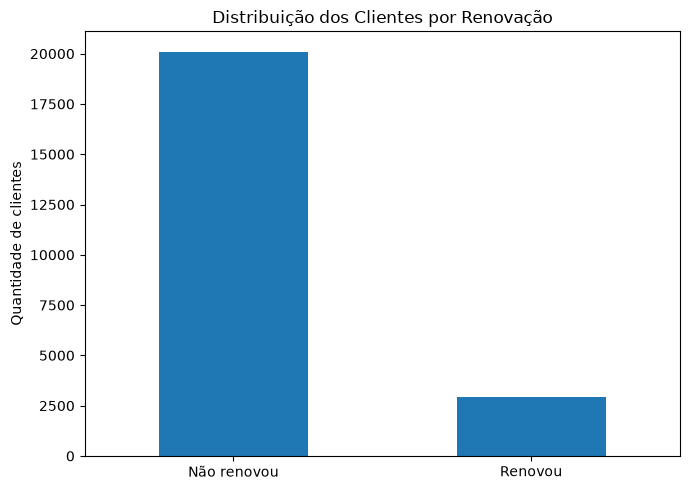

In [5]:
ax = distribuicao.plot(
    kind="bar",
    figsize=(7, 5)
)

ax.set_title("Distribuição dos Clientes por Renovação")
ax.set_xlabel("")
ax.set_ylabel("Quantidade de clientes")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> **Insight:** A base apresenta forte desbalanceamento entre as classes. A maioria dos clientes não renovou sua apólice, enquanto uma parcela menor realizou a renovação. Esse desbalanceamento deverá ser considerado nas etapas estatísticas e, principalmente, na construção e avaliação dos modelos preditivos.

## 2.4. Renovação por faixa etária

In [6]:
df["Faixa_Idade"] = pd.cut(
    df["Idade"],
    bins=[18, 30, 40, 50, 60, 100],
    labels=[
        "19-30",
        "31-40",
        "41-50",
        "51-60",
        "61+"
    ]
)

In [7]:
idade_renovacao = (
    df.groupby("Faixa_Idade", observed=True)
      .agg(
          clientes=("Flag_Renovou", "count"),
          renovacoes=("Flag_Renovou", "sum"),
          taxa_renovacao=("Flag_Renovou", "mean")
      )
)

idade_renovacao["taxa_renovacao"] *= 100

idade_renovacao

,clientes,renovacoes,taxa_renovacao
Faixa_Idade,,,
19-30,2974,514,17.283120
31-40,8198,1097,13.381313
41-50,6701,816,12.177287
51-60,2841,318,11.193242
61+,2346,209,8.908781


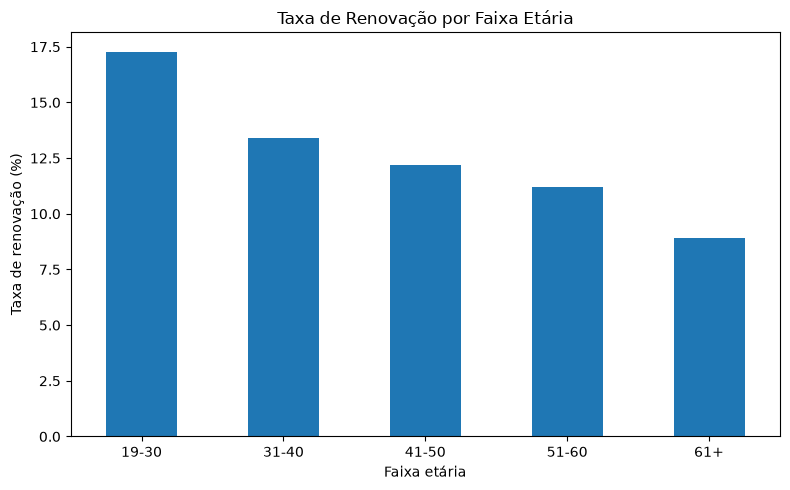

In [8]:
ax = idade_renovacao["taxa_renovacao"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Taxa de Renovação por Faixa Etária")
ax.set_xlabel("Faixa etária")
ax.set_ylabel("Taxa de renovação (%)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> **Insight** Observa-se uma tendência de redução da taxa de renovação conforme aumenta a idade. A taxa de renovação passa de aproximadamente 17,3% entre clientes de 19 a 30 anos para 8,9% entre clientes com 61 anos ou mais. Essa diferença representa uma hipótese relevante para investigação estatística.

## 2.5. Renovação por tempo de apólice

In [9]:
df["Faixa_Tempo_Apolice"] = pd.cut(
    df["Tempo_Apolice"],
    bins=[-1, 1, 3, 5, 10, 20],
    labels=[
        "0-1",
        "2-3",
        "4-5",
        "6-10",
        "11+"
    ]
)

In [10]:
tempo_renovacao = (
    df.groupby("Faixa_Tempo_Apolice", observed=True)
      .agg(
          clientes=("Flag_Renovou", "count"),
          renovacoes=("Flag_Renovou", "sum"),
          taxa_renovacao=("Flag_Renovou", "mean")
      )
)

tempo_renovacao["taxa_renovacao"] *= 100

tempo_renovacao

,clientes,renovacoes,taxa_renovacao
Faixa_Tempo_Apolice,,,
0-1,13189,1866,14.148154
2-3,3847,519,13.491032
4-5,1683,218,12.953060
6-10,3942,324,8.219178
11+,399,27,6.766917


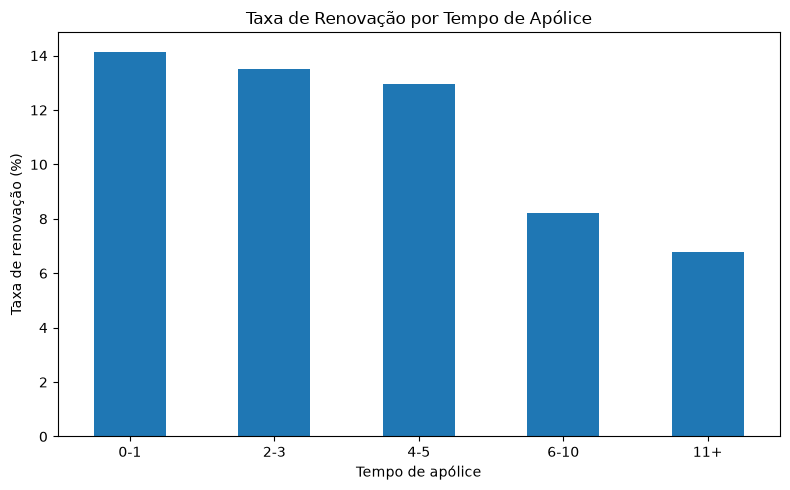

In [11]:
ax = tempo_renovacao["taxa_renovacao"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Taxa de Renovação por Tempo de Apólice")
ax.set_xlabel("Tempo de apólice")
ax.set_ylabel("Taxa de renovação (%)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> **Insight:** Existe uma redução consistente da taxa de renovação conforme aumenta o tempo de apólice. Clientes com 0-1 ano de apólice apresentam taxa de renovação de aproximadamente 14,1%, enquanto clientes com 6-10 anos apresentam 8,2%. Esse comportamento sugere que clientes de longa permanência podem representar um segmento relevante para estratégias de retenção.

## 2.6. Renovação por faixa de prêmio

In [18]:
df["Faixa_Premio"] = pd.qcut(
    df["Premio_Final"],
    q=4,
    duplicates="drop"
)

In [19]:
premio_renovacao = (
    df.groupby("Faixa_Premio", observed=True)
      .agg(
          clientes=("Flag_Renovou", "count"),
          renovacoes=("Flag_Renovou", "sum"),
          taxa_renovacao=("Flag_Renovou", "mean")
      )
)

premio_renovacao["taxa_renovacao"] *= 100

premio_renovacao

,clientes,renovacoes,taxa_renovacao
Faixa_Premio,,,
"(46.549, 232.838]",5765,605,10.494363
"(232.838, 312.25]",5770,726,12.582322
"(312.25, 448.37]",5760,774,13.437500
"(448.37, 2948.05]",5765,849,14.726800


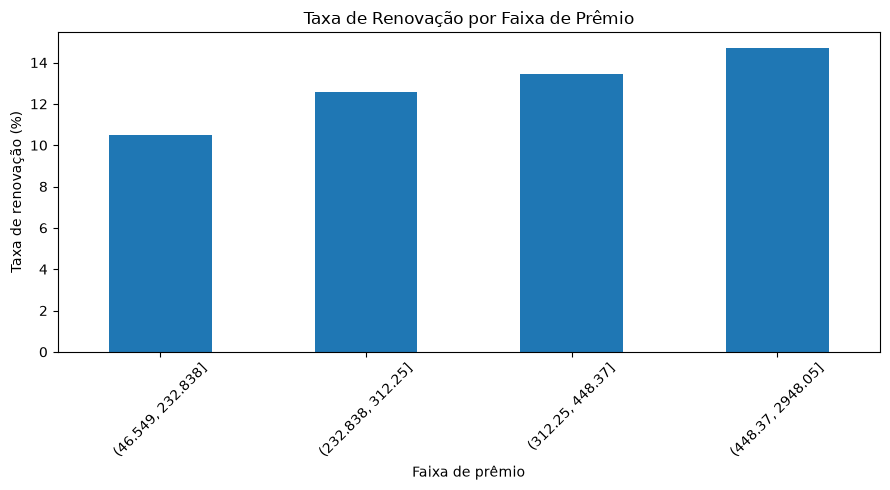

In [20]:
ax = premio_renovacao["taxa_renovacao"].plot(
    kind="bar",
    figsize=(9, 5)
)

ax.set_title("Taxa de Renovação por Faixa de Prêmio")
ax.set_xlabel("Faixa de prêmio")
ax.set_ylabel("Taxa de renovação (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

> **Insight:** Observa-se aumento da taxa de renovação conforme aumenta o prêmio final. Clientes pertencentes ao maior quartil de prêmio apresentam taxa de renovação de aproximadamente 14,7%, enquanto o menor quartil apresenta 10,5%. Esse resultado sugere uma possível associação entre o valor do prêmio e a probabilidade de renovação, que será investigada nas próximas etapas.

## 2.7. Renovação por Perfil de Risco

In [21]:
perfil_renovacao = (
    df.groupby("Perfil_Risco")
      .agg(
          clientes=("Flag_Renovou", "count"),
          renovacoes=("Flag_Renovou", "sum"),
          taxa_renovacao=("Flag_Renovou", "mean")
      )
      .sort_values("taxa_renovacao")
)

perfil_renovacao["taxa_renovacao"] *= 100

perfil_renovacao

,clientes,renovacoes,taxa_renovacao
Perfil_Risco,,,
up,869,85,9.781358
stable,12036,1231,10.227650
down,10155,1638,16.129985


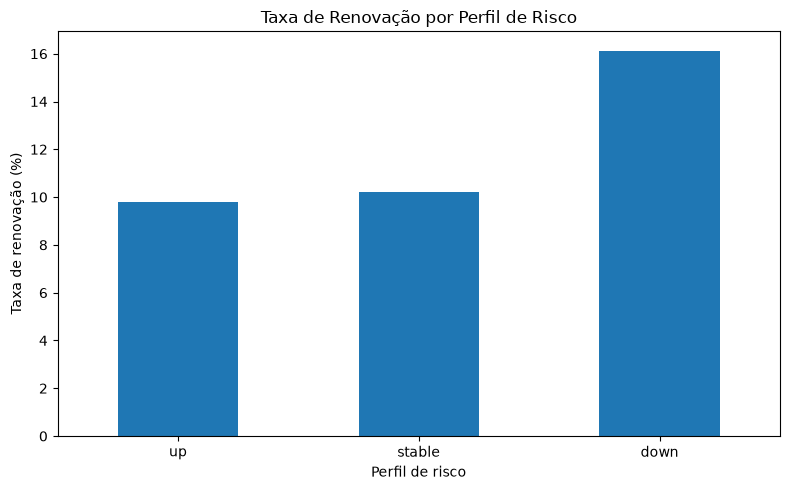

In [22]:
ax = perfil_renovacao["taxa_renovacao"].plot(
    kind="bar",
    figsize=(8, 5)
)

ax.set_title("Taxa de Renovação por Perfil de Risco")
ax.set_xlabel("Perfil de risco")
ax.set_ylabel("Taxa de renovação (%)")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> **Insight:** Foram observadas diferenças relevantes entre os grupos de `Perfil_Risco`. O grupo `down` apresentou taxa de renovação superior aos grupos `stable` e `up`, resultado que não corresponde necessariamente à expectativa inicial e deverá ser investigado. Neste momento, o resultado deve ser tratado como uma associação observada, sem interpretação causal.

## 2.8. Renovação por região

In [23]:
regiao_renovacao = (
    df.groupby("Veic_Regiao")
      .agg(
          clientes=("Flag_Renovou", "count"),
          renovacoes=("Flag_Renovou", "sum"),
          taxa_renovacao=("Flag_Renovou", "mean")
      )
      .sort_values("taxa_renovacao")
)

regiao_renovacao["taxa_renovacao"] *= 100

regiao_renovacao

,clientes,renovacoes,taxa_renovacao
Veic_Regiao,,,
Reg2,556,41,7.374101
Reg5,2391,240,10.037641
Reg1,618,65,10.517799
Reg7,3156,374,11.850444
Reg6,1119,135,12.064343
Reg3,1827,223,12.205802
Reg4,4325,548,12.670520
Reg8,3074,399,12.979831
Reg10,1057,139,13.150426


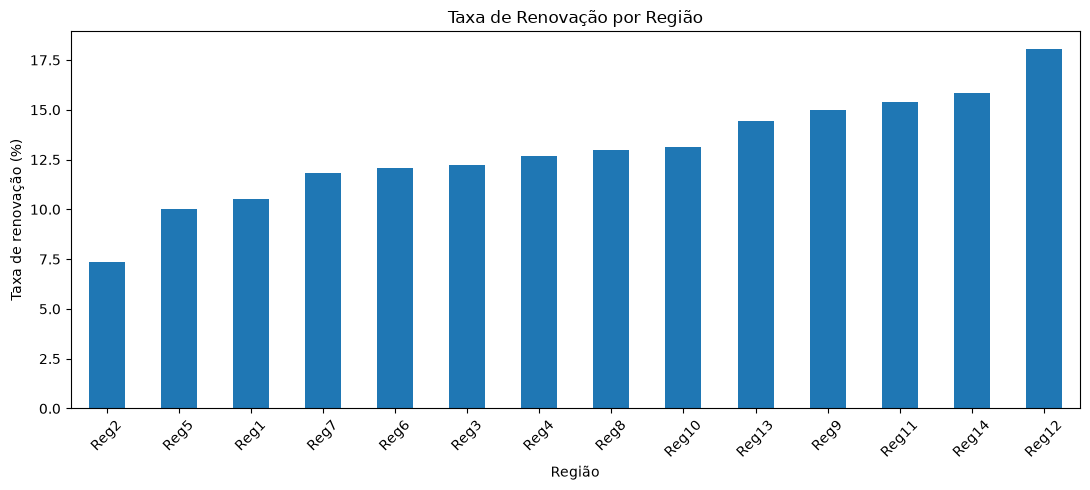

In [24]:
ax = regiao_renovacao["taxa_renovacao"].plot(
    kind="bar",
    figsize=(11, 5)
)

ax.set_title("Taxa de Renovação por Região")
ax.set_xlabel("Região")
ax.set_ylabel("Taxa de renovação (%)")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

> **Insight:** Existe uma diferença relevante entre as regiões. A taxa de renovação varia de aproximadamente 7,4% na Reg2 até 18,0% na Reg12. Essa diferença sugere que fatores associados à região podem estar relacionados ao comportamento de renovação. A associação será investigada estatisticamente no próximo notebook.

## 2.9. Resumo das hipóteses

In [25]:
hipoteses = pd.DataFrame({
    "Variavel": [
        "Idade",
        "Tempo_Apolice",
        "Premio_Final",
        "Perfil_Risco",
        "Veic_Regiao"
    ],
    "Hipotese": [
        "Clientes mais jovens apresentam maior taxa de renovação",
        "Clientes com maior tempo de apólice apresentam menor taxa de renovação",
        "Clientes com maior prêmio apresentam maior taxa de renovação",
        "A taxa de renovação varia entre os perfis de risco",
        "A taxa de renovação varia entre regiões"
    ]
})

hipoteses

,Variavel,Hipotese
0,Idade,Clientes mais jovens apresentam maior taxa de ...
1,Tempo_Apolice,Clientes com maior tempo de apólice apresentam...
2,Premio_Final,Clientes com maior prêmio apresentam maior tax...
3,Perfil_Risco,A taxa de renovação varia entre os perfis de r...
4,Veic_Regiao,A taxa de renovação varia entre regiões


## Conclusão

A análise exploratória identificou diferenças nas taxas de renovação de acordo
com características dos clientes, apólices e veículos.

Os principais padrões observados foram:

- redução da taxa de renovação conforme aumenta a idade;
- redução da taxa de renovação conforme aumenta o tempo de apólice;
- aumento da taxa de renovação nas faixas superiores de prêmio;
- diferenças entre os grupos de `Perfil_Risco`;
- diferenças relevantes entre as regiões.

Esses resultados representam hipóteses exploratórias e não devem ser
interpretados como relações causais.

No próximo notebook será realizada uma análise estatística para avaliar a
existência e a força das associações identificadas.